## module 3e — real plans: label, curate, transfer

the layout model's ceiling is its synthetic teacher; real landscape drawings carry the
spatial statistics rules can't fake. plan symbols are mostly circles, so labeling them
is week-3 vision: **hough proposes, edges dispose** (perimeter gradient support + nms),
plus an **ensemble genre gate** (flat fills · light paper · crisp circles · a drawn
grid) that separates true top-down plans from photos, watercolors and clipart — every
signal below was calibrated against labeled examples, not guessed.

the corpus in `data/real_plans/` is harvested by `scripts/harvest_real_plans.py`
(garden gate magazine's plan articles + almanac's layout library; local-only and
gitignored — publisher images, provenance in `sources.csv`). species aren't readable
from a drawing, so semantics stay synthetic: **pretrain on real geometry
(size-pseudo-labeled), finetune on the designed corpus** — the week-4 transfer recipe,
a/b'd against a scratch model at the *same finetune budget*.

runtime: ~20-25 min on a small gpu (designed corpus ~6 min, two 15-epoch arms ~8 min,
evals ~6 min). checkpointed + resumable per arm.

In [1]:
# get bvtrain (shared plumbing): locally it's ../bvtrain; on colab/kaggle clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision")
sys.path[:0] = [p for p in _CANDS if os.path.isdir(f"{p}/bvtrain")]

import glob, hashlib, json, math, random
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm, trange

from bvtrain import garden as g

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.facecolor"] = "linen"
DEV

'cuda'

### the labeler

In [2]:
def _edge_support(mag, cx, cy, r, thresh=28.0, n=48):
    h, w = mag.shape
    hit = 0
    for k in range(n):
        a = 2 * math.pi * k / n
        x, y = int(cx + r * math.cos(a)), int(cy + r * math.sin(a))
        if 0 <= x < w and 0 <= y < h and mag[y, x] > thresh:
            hit += 1
    return hit / n


def extract_circles(pil_img, min_r_frac=0.008, max_r_frac=0.12, support=0.6):
    arr = np.array(pil_img.convert("L"))
    h, wpx = arr.shape
    blur = cv2.GaussianBlur(arr, (5, 5), 1.2)
    gx = cv2.Sobel(blur, cv2.CV_32F, 1, 0)
    gy = cv2.Sobel(blur, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)
    mn = max(4, int(min(h, wpx) * min_r_frac))
    mx = int(min(h, wpx) * max_r_frac)
    cs = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=mn * 2,
                          param1=120, param2=42, minRadius=mn, maxRadius=mx)
    if cs is None:
        return []
    cands = [(float(x), float(y), float(r), _edge_support(mag, x, y, r))
             for x, y, r in cs[0]]
    cands = sorted([c for c in cands if c[3] >= support], key=lambda c: -c[3])
    kept = []
    for x, y, r, sup in cands:
        if all(math.hypot(x - kx, y - ky) > 0.7 * max(r, kr) for kx, ky, kr, _ in kept):
            kept.append((x, y, r, sup))
    return kept

### does it work? (known ground truth)

In [3]:
def draw_plan_drawing(plan, w, d, px=120, style="outline"):
    W, H = int((w + 1) * px), int((d + 1) * px)
    img = Image.new("RGB", (W, H), (250, 248, 242))
    dr = ImageDraw.Draw(img)
    dr.rectangle([px // 2, px // 2, W - px // 2, H - px // 2], outline=(80, 80, 80), width=2)
    gt = []
    for i, x, y, r in plan:
        cx, cy = (0.5 + x) * px, (0.5 + d - y) * px
        rp = r * px
        fill = (205, 220, 205) if style == "tinted" else None
        dr.ellipse([cx - rp, cy - rp, cx + rp, cy + rp], outline=(40, 40, 40),
                   width=max(2, int(rp * 0.06)), fill=fill)
        gt.append((cx, cy, rp))
    return img, gt


def prf(gt, det, tol=0.5):
    used, tp = set(), 0
    for cx, cy, r in gt:
        best, bj = 1e9, -1
        for j, (dx, dy, dr_, _) in enumerate(det):
            if j in used:
                continue
            dist = math.hypot(dx - cx, dy - cy)
            if dist < best and dist < tol * r and abs(dr_ - r) < 0.5 * r:
                best, bj = dist, j
        if bj >= 0:
            used.add(bj)
            tp += 1
    return (tp / len(det) if det else 0.0), (tp / len(gt) if gt else 0.0)


rows = []
for style in ("outline", "tinted"):
    for k in range(4):
        w, d, sun = g.rand_site()
        plan = g.repair(g.gen_plan2(w, d, sun), w, d)
        img, gt = draw_plan_drawing(plan, w, d, style=style)
        p, r_ = prf(gt, extract_circles(img))
        rows.append({"style": style, "gt": len(gt), "precision": round(p, 2), "recall": round(r_, 2)})
pd.DataFrame(rows)

,style,gt,precision,recall
0,outline,46,1.0,0.96
1,outline,13,1.0,0.92
2,outline,20,1.0,0.95
3,outline,35,1.0,0.94
4,tinted,22,1.0,0.91
5,tinted,35,1.0,0.94
6,tinted,48,1.0,0.94
7,tinted,35,1.0,0.94


### the curated corpus (ensemble genre gate)

four signals, each calibrated on labeled examples: **flat fills** (drawings, not
photos), **light paper**, **crisp circles** (mean edge support), and **a drawn grid**
(long axis-aligned lines — watercolor perspectives have none; this killed the last
impostors). the historical engraving seed fails on detection density — kept in the
folder as the standing negative example.

15 images in data/real_plans -> 14 pass the gate | by prefix: {'alm': 5, 'com': 1, 'gg_': 9}


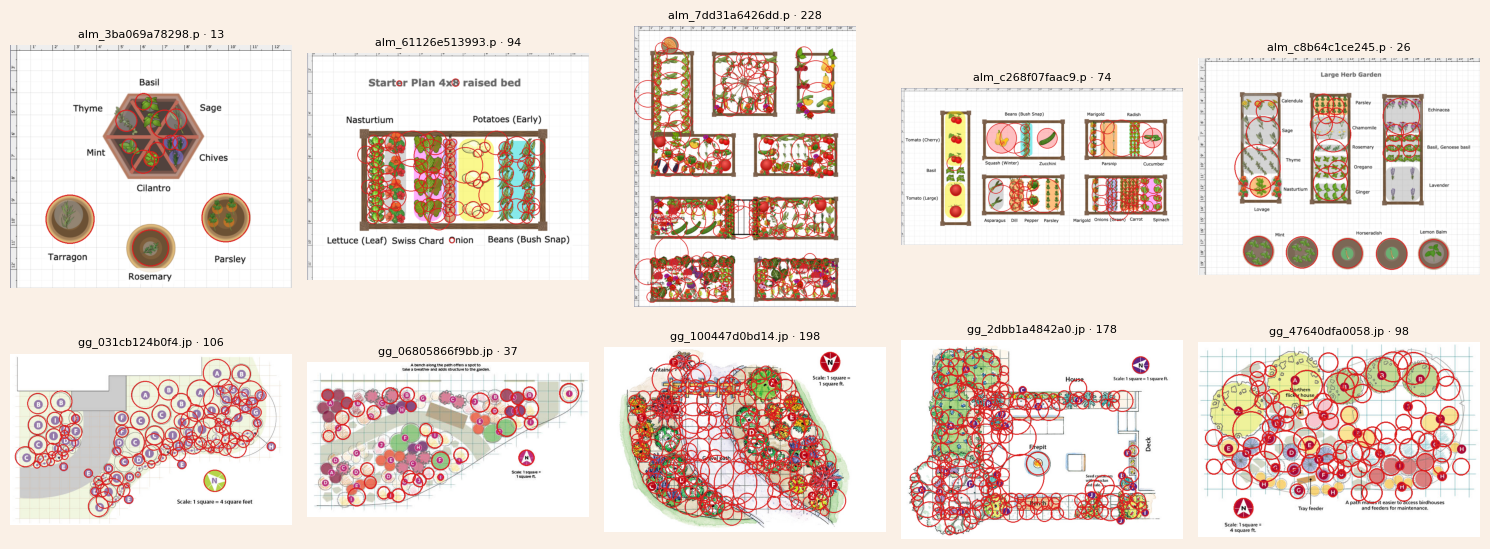

In [4]:
def genre_gate(im):
    arr = np.array(im.convert("L"))
    gx = cv2.Sobel(arr, cv2.CV_32F, 1, 0)
    gy = cv2.Sobel(arr, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)
    flat = float((mag < 12).mean())
    white = float((arr > 200).mean())
    det = extract_circles(im)
    ms = float(np.mean([d[3] for d in det])) if det else 0.0
    edges = cv2.Canny(arr, 40, 120)
    h, w = arr.shape
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=80,
                            minLineLength=int(min(h, w) * 0.25), maxLineGap=4)
    ngrid = 0
    if lines is not None:
        for ln in lines:
            x1, y1, x2, y2 = ln.ravel().tolist()
            if abs(y2 - y1) <= 2 or abs(x2 - x1) <= 2:
                ngrid += 1
    ok = flat >= 0.35 and white >= 0.5 and ms >= 0.8 and 8 <= len(det) <= 250 and ngrid >= 6
    return ok, det

paths = sorted(sum([glob.glob(f"../data/real_plans/*.{e}") for e in ("png", "jpg", "jpeg", "gif", "tif")], []))
real_dets = []
shown = 0
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for p in paths:
    try:
        im = Image.open(p)
        im.thumbnail((1400, 1400))
        im = im.convert("RGB")
    except Exception:
        continue
    ok, det = genre_gate(im)
    if ok:
        real_dets.append(det)
        if shown < 10:
            ov = im.copy()
            dr = ImageDraw.Draw(ov)
            for x, y, r, _ in det:
                dr.ellipse([x - r, y - r, x + r, y + r], outline=(220, 30, 30), width=3)
            axes[shown].imshow(ov)
            axes[shown].set_title(f"{os.path.basename(p)[:18]} · {len(det)}", fontsize=8)
            axes[shown].axis("off")
            shown += 1
for ax in axes[shown:]:
    ax.axis("off")
plt.tight_layout()
srcs = Counter(os.path.basename(p)[:3] for p in paths)
print(f"{len(paths)} images in data/real_plans -> {len(real_dets)} pass the gate | by prefix: {dict(srcs)}")

### real geometry → canvases (pseudo-labels by size)

species aren't readable, symbol size is: each detection maps to the palette species
with the closest mature spread. height banding, drift shapes and massing come from the
real plan. augmentation: mirror + one grid-jitter resample per variant.

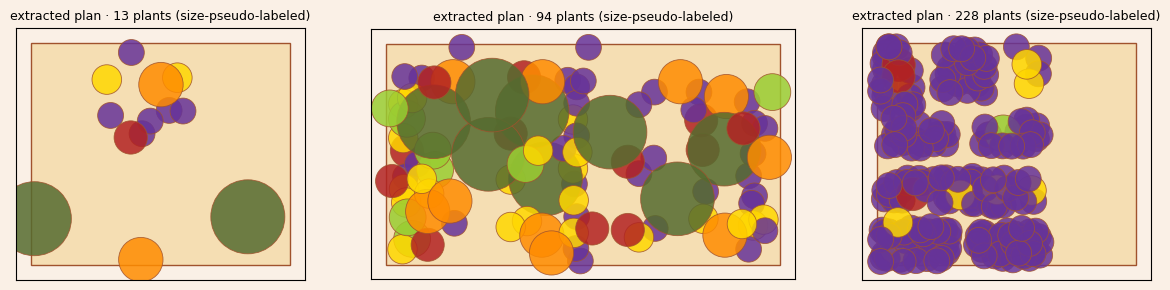

In [5]:
def detections_to_plan(det):
    # robust extent (2-98th pct of centers, padded by median radius) + one
    # aspect-preserving scale — the v1 per-axis clamp squashed square plans
    xs = np.array([x for x, _, _, _ in det])
    ys = np.array([y for _, y, _, _ in det])
    rmed = float(np.median([r for _, _, r, _ in det]))
    x0, x1 = np.percentile(xs, 2) - rmed, np.percentile(xs, 98) + rmed
    y0, y1 = np.percentile(ys, 2) - rmed, np.percentile(ys, 98) + rmed
    xext, yext = max(x1 - x0, 1.0), max(y1 - y0, 1.0)
    scale = min(7.5 / xext, 3.0 / yext)
    w = min(max(xext * scale, 3.5), 7.5)
    d = min(max(yext * scale, 1.8), 3.0)
    plan = []
    for x, y, r, _ in det:
        px = min(max((x - x0) * scale, 0.05), w - 0.05)
        py = min(max((y - y0) * scale, 0.05), d - 0.05)
        rm = r * scale
        i = min(range(len(g.PALETTE)), key=lambda k: abs(g.PALETTE[k]["s"] / 200 - rm))
        plan.append((i, px, d - py, g.PALETTE[i]["s"] / 200))
    return plan, w, d

real_plans = [detections_to_plan(det) for det in real_dets]
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (plan, w, d) in zip(axes, real_plans):
    g.show_plan(plan, w, d, ax, f"extracted plan · {len(plan)} plants (size-pseudo-labeled)")
plt.tight_layout()

### transfer experiment — pretrain on real, finetune on designed

fair fight at equal finetune budget: **scratch-15** (random init → 15 epochs on the
designed corpus) vs **pre-15** (pretrain on the real canvases → same 15 epochs).
reference: 13's fully-trained 40-epoch model scored 0.891 best-of-8+repair. sun is
unknown for real drawings, so real canvases carry `sun = 1` — pretraining teaches
geometry, finetuning fixes semantics.

In [6]:
# canvas scheme mirrors notebook 13 exactly
NX, NY, NW, ND, NCNT = 32, 12, 9, 7, 10
NSP = len(g.PALETTE)
MASK  = 0
T_W   = 1
T_D   = T_W + NW
T_SUN = T_D + ND
T_CNT = T_SUN + 3
T_SP  = T_CNT + NCNT
T_X   = T_SP + 1 + NSP
T_Y   = T_X + 1 + NX
VOCAB = T_Y + 1 + NY
MAXP  = 60
L     = 3 + NSP + 3 * MAXP

FAM = ([(T_W, T_D), (T_D, T_SUN), (T_SUN, T_CNT)] + [(T_CNT, T_SP)] * NSP
       + [(T_SP, T_X), (T_X, T_Y), (T_Y, VOCAB)] * MAXP)
FAM_MASK = torch.full((L, VOCAB), float("-inf"))
for p, (lo, hi) in enumerate(FAM):
    FAM_MASK[p, lo:hi] = 0
MASKABLE = torch.zeros(L, dtype=torch.bool); MASKABLE[3:] = True

def site_tokens(w, d, sun):
    return [T_W + min(NW - 1, int((w - 3.5) / 0.5)),
            T_D + min(ND - 1, int((d - 1.8) / 0.2)), T_SUN + sun]

def encode(plan, w, d, sun):
    counts = Counter(i for i, _, _, _ in plan)
    t = site_tokens(w, d, sun) + [T_CNT + min(NCNT - 1, counts.get(i, 0)) for i in range(NSP)]
    for i, x, y, r in sorted(plan, key=lambda p: (-p[2], p[1]))[:MAXP]:
        t += [T_SP + 1 + i, T_X + 1 + min(NX - 1, int(x / w * NX)),
              T_Y + 1 + min(NY - 1, int(y / d * NY))]
    t += [T_SP, T_X, T_Y] * (MAXP - (len(t) - 3 - NSP) // 3)
    return t

def decode(tokens, w, d):
    plan = []
    for k in range(3 + NSP, L, 3):
        s, x, y = tokens[k] - T_SP, tokens[k + 1] - T_X, tokens[k + 2] - T_Y
        if s <= 0 or x <= 0 or y <= 0:
            continue
        i = s - 1
        plan.append((i, (x - 0.5) / NX * w, (y - 0.5) / NY * d, g.PALETTE[i]["s"] / 200))
    return plan

def jitter(plan, w, d):
    out = []
    for i, x, y, r in plan:
        out.append((i, min(max(x + random.gauss(0, 0.15), 0.05), w - 0.05),
                    min(max(y + random.gauss(0, 0.1), 0.05), d - 0.05), r))
    return out

real_canvases = []
for plan, w, d in real_plans:
    mirrored = [(i, w - x, y, r) for i, x, y, r in plan]
    for variant in (plan, mirrored):
        real_canvases.append(encode(variant, w, d, 1))
        real_canvases.append(encode(jitter(variant, w, d), w, d, 1))
Xreal = torch.tensor(real_canvases)
print("real canvases (with augmentation):", Xreal.shape)

real canvases (with augmentation): torch.Size([56, 199])


In [7]:
N_TRAIN, N_VAL = 12000, 500
sites = [g.rand_site() for _ in range(N_TRAIN + N_VAL)]
X = torch.tensor([encode(g.repair(g.gen_plan2(w, d, s), w, d), w, d, s)
                  for w, d, s in tqdm(sites, desc="designed corpus")])
Xtr = X[:N_TRAIN]

class LayoutMDM(nn.Module):
    def __init__(self, v=VOCAB, dm=192, heads=6, layers=6, ctx=L):
        super().__init__()
        self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
        blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
        self.head = nn.Linear(dm, v)
    def forward(self, x):
        h = self.tok(x) + self.pos(torch.arange(x.shape[1], device=x.device))
        return self.head(self.tf(h))

def masked_batch(xb, gen=None):
    B = xb.shape[0]
    ratio = torch.cos(torch.rand(B, 1, generator=gen) * math.pi / 2).clamp(min=0.05)
    m = (torch.rand(B, L, generator=gen) < ratio) & MASKABLE
    xin = xb.clone(); xin[m] = MASK
    return xin, m

def train_arm(model, data, epochs, run_name, batch=64, lr=3e-4):
    sig = hashlib.md5(json.dumps([run_name, epochs, len(data), 192, 6, SEED, "v2norm" if "pre" in run_name else "v1"],
                                 sort_keys=True).encode()).hexdigest()[:10]
    last = g.ckpt_dir() / f"{run_name}_last.pt"
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    start_ep, hist = 0, []
    if last.exists():
        ck = torch.load(last, map_location=DEV, weights_only=False)
        if ck.get("sig") == sig:
            model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
            start_ep, hist = ck["epoch"], ck["hist"]
            print(f"  {run_name}: resumed at epoch {start_ep}")
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(data),
                                         batch_size=batch, shuffle=True)
    for ep in range(start_ep, epochs):
        model.train(); tot = n = 0
        bar = tqdm(loader, desc=f"{run_name} {ep + 1}/{epochs}", leave=False)
        for (xb,) in bar:
            xin, m = masked_batch(xb)
            loss = F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item(); n += 1
            bar.set_postfix(loss=f"{tot / n:.3f}")
        hist.append(tot / n)
        torch.save({"sig": sig, "model": model.state_dict(), "opt": opt.state_dict(),
                    "epoch": ep + 1, "hist": hist}, last)
        print(f"  {run_name} epoch {ep + 1:2d}  loss {tot / n:.3f}")
    return model

FT_EPOCHS = 15
print("arm 1: scratch-15")
m_scratch = train_arm(LayoutMDM().to(DEV), Xtr, FT_EPOCHS, "garden_maskdiff_scratch15")
print("arm 2: pretrain on real, then finetune-15")
m_pre = LayoutMDM().to(DEV)
m_pre = train_arm(m_pre, Xreal, 60, "garden_maskdiff_realpre", batch=16)
m_pre = train_arm(m_pre, Xtr, FT_EPOCHS, "garden_maskdiff_pre15")

designed corpus:   0%|          | 0/12500 [00:00<?, ?it/s]

arm 1: scratch-15


garden_maskdiff_scratch15 1/15:   0%|          | 0/188 [00:00<?, ?it/s]

  garden_maskdiff_scratch15 epoch  1  loss 1.689


garden_maskdiff_scratch15 2/15:   0%|          | 0/188 [00:00<?, ?it/s]

...

  garden_maskdiff_pre15 epoch 13  loss 1.033


garden_maskdiff_pre15 14/15:   0%|          | 0/188 [00:00<?, ?it/s]

  garden_maskdiff_pre15 epoch 14  loss 1.032


garden_maskdiff_pre15 15/15:   0%|          | 0/188 [00:00<?, ?it/s]

  garden_maskdiff_pre15 epoch 15  loss 1.026


In [8]:
FAM_DEV = FAM_MASK.to(DEV)

@torch.no_grad()
def sample_plans(model, plan_sites, steps=12, temp=1.0):
    B = len(plan_sites)
    canvas = torch.zeros(B, L, dtype=torch.long)
    fixed = torch.zeros(B, L, dtype=torch.bool)
    for b, (w, d, sun) in enumerate(plan_sites):
        canvas[b, :3] = torch.tensor(site_tokens(w, d, sun)); fixed[b, :3] = True
    canvas, fixed = canvas.to(DEV), fixed.to(DEV)
    canvas[~fixed] = MASK
    M0 = (canvas == MASK).sum(1)
    for t in range(steps):
        logits = model(canvas) + FAM_DEV
        probs = F.softmax(logits / temp, -1)
        samp = torch.multinomial(probs.reshape(-1, VOCAB), 1).reshape(B, L)
        conf = probs.gather(-1, samp.unsqueeze(-1)).squeeze(-1)
        still = canvas == MASK
        canvas = torch.where(still, samp, canvas)
        n_mask = (M0.float() * math.cos(math.pi / 2 * (t + 1) / steps)).long()
        conf = conf.masked_fill(~still, float("inf"))
        for b in range(B):
            if n_mask[b] > 0:
                canvas[b, conf[b].argsort()[:n_mask[b]]] = MASK
    return [decode(canvas[b].tolist(), s[0], s[1]) for b, s in enumerate(plan_sites)]

def best_of(model, site, n=8):
    plans = sample_plans(model, [site] * n)
    plans = [g.repair(p, site[0], site[1]) for p in plans]
    return max(plans, key=lambda p: g.score2(p, *site)["score"])

eval_sites = [g.rand_site() for _ in range(60)]

def score_model(model, search=False):
    if search:
        plans = [best_of(model, s) for s in tqdm(eval_sites, desc="best-of-8", leave=False)]
    else:
        plans = sample_plans(model, eval_sites)
    return pd.DataFrame([g.score2(p, w, d, s)
                         for p, (w, d, s) in zip(plans, eval_sites)]).mean().round(3)

comp = pd.DataFrame({
    "scratch-15 ×1": score_model(m_scratch),
    "pre-15 ×1": score_model(m_pre),
    "scratch-15 best-of-8+repair": score_model(m_scratch, search=True),
    "pre-15 best-of-8+repair": score_model(m_pre, search=True),
})
comp

best-of-8:   0%|          | 0/60 [00:00<?, ?it/s]

best-of-8:   0%|          | 0/60 [00:00<?, ?it/s]

,scratch-15 ×1,pre-15 ×1,scratch-15 best-of-8+repair,pre-15 best-of-8+repair
overlap,0.951,0.962,0.999,0.999
height,0.996,0.994,0.990,0.983
cover,0.690,0.570,0.744,0.580
drift,0.349,0.387,0.824,0.866
sun,0.999,0.999,1.000,1.000
color,0.693,0.745,0.747,0.799
bloom,0.819,0.852,0.829,0.855
score,0.785,0.787,0.876,0.869


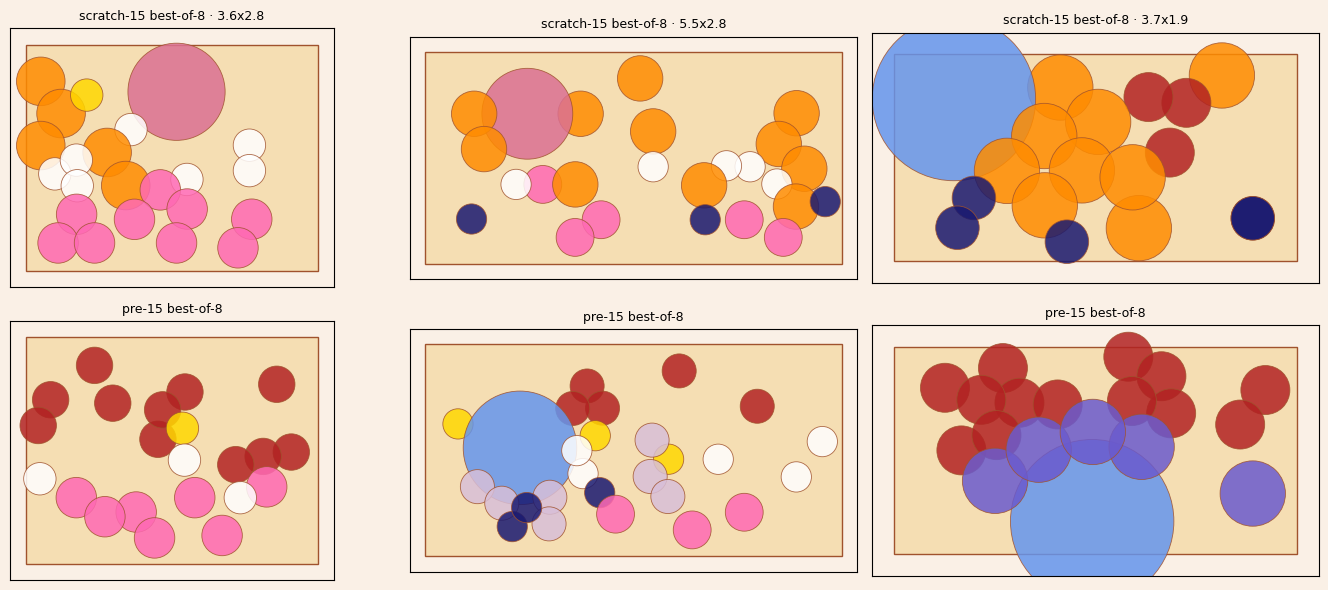

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for c in range(3):
    site = g.rand_site()
    g.show_plan(best_of(m_scratch, site), site[0], site[1], axes[0][c],
                f"scratch-15 best-of-8 · {site[0]}x{site[1]}")
    g.show_plan(best_of(m_pre, site), site[0], site[1], axes[1][c], "pre-15 best-of-8")
plt.tight_layout()

### takeaways

- the labeler holds on ground truth (precision 1.0, recall 0.91-0.96) and the ensemble
  gate is clean: 14 of 15 harvested images pass; the engraving is correctly rejected.
  the aspect-preserving normalization (robust percentile extents, one scale factor)
  fixed the earlier front-edge squash — extracted canvases now carry full-bed massing.
- **the transfer experiment remains a measured tie with corrected geometry**: scratch-15
  vs pre-15 at 0.785 vs 0.787 (×1) and 0.876 vs 0.869 (best-of-8+repair). a real
  sub-signal: the pretrained arm is consistently better on drift (0.866 vs 0.824) and
  color (0.799 vs 0.747) but plants sparser (cover 0.580 vs 0.744) — real plans' looser
  massing transfers as under-planting. no net win claimed.
- conclusion: at 14 plans, training budget dominates initialization (both arms trail the
  40-epoch 0.891). the pipeline — harvest → hough+edge labeler → calibrated genre gate →
  pseudo-labeled canvases → budget-matched a/b — is the deliverable; the corpus is the
  bottleneck. grow it via `scripts/harvest_real_plans.py` or by dropping circle-symbol
  plans into `data/real_plans/`, and rerun this notebook at ≥50 plans.